# Regression - Modellvergleich

Zur Modellierung des Betrugsrisikos bei Self-Checkout-Transaktionen wird ein mehrstufiger Machine-Learning-Ansatz umgesetzt. Grundlage bilden Transaktionsdaten, aus denen zunächst die Zielgröße Damage entfernt wird, um Data Leakage zu vermeiden. Anschließend erfolgt eine stratifizierte Aufteilung der Daten in Trainings- und Testdatensätze, um eine repräsentative Verteilung der Klassen (FRAUD/NORMAL) sicherzustellen.

Alle Vorverarbeitungsschritte werden in einer einheitlichen Preprocessing-Pipeline zusammengefasst und konsistent sowohl auf die Trainings- als auch auf die Testdaten angewendet.

Für das eigentliche Modelltraining werden verschiedene Regressionsmodelle in Pipelines integriert, bestehend aus Preprocessing und Modellalgorithmus. Ziel ist es, den zu erwartenden Schadenswert pro Transaktion vorherzusagen. Im Anschluss wird für jedes Modell ein optimaler Schwellenwert bestimmt. Hierzu werden iterativ 100 gleichmäßig verteilte Schwellenwerte zwischen 0 und dem maximal vorhergesagten Schaden getestet, jeweils die projektspezifische Kostenfunktion berechnet und derjenige Schwellenwert ausgewählt, der die wirtschaftlich beste Balance zwischen False Positives, False Negatives und tatsächlichem Schaden erzielt.

Die Modelle werden abschließend anhand der Kostenfunktion sowie klassischer Klassifikationsmetriken wie Precision, Recall, F1-Score und ROC-AUC bewertet.

## Imports

In [ ]:
# Standard Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import logging

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, 
    roc_auc_score, RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay, accuracy_score
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Regressoren
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# Logging & Warnings Setup
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
warnings.filterwarnings("ignore")

# Preprocessor laden
# X enthält die features der transaktionen (inklusive den 'damage') und y die klasse (FRAUD=1, NORMAL=0) für jede transaktion.
from pipeline.data_pipeline import preprocessor, X, y


## 1. Datenaufteilung


In [2]:
# damage extrahieren und aus X entfernen
damage_series = X['damage'].copy()
X = X.drop(columns=['damage'])

# stratify=y sorgt für eine proportionale Aufteilung der Klassen in Train/Test, wichtig bei unbalancierten Datensets.
if isinstance(y, pd.Series) and y.nunique() > 1 and y.notnull().all():
    stratify_param = y
else:
    stratify_param = None

X_train, X_test, y_train, y_test, damage_train, damage_test = train_test_split(
    X, y, damage_series,
    test_size=0.2,
    random_state=42,
    stratify=stratify_param
)


## 2. Zielfunktion definieren

In [3]:
def custom_objective_score(y_true, y_pred, damage_series):
    """
    Custom Zielfunktion:
    Score = -Summe Schaden der FN + (5 * TP) - (10 * FP)
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])	# Confusion Matrix berechnen
    TN, FP, FN, TP = cm.ravel()
    
    fn_mask = (y_true == 1) & (y_pred == 0)		# Ermitteln des gesamten Schadens aus den False Negatives
    sum_damage_fn = damage_series[fn_mask].sum()
    
    score = -sum_damage_fn + (5 * TP) - (10 * FP)	# Berechnung des Ziel-Scores nach unserer Kostenfunktion
    return float(score)


## 3. Modellliste für initiale Tests

In [4]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=4),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=4),
    "LightGBM": lgb.LGBMRegressor(n_estimators=100, random_state=42, n_jobs=4),
    "CatBoost": cb.CatBoostRegressor(iterations=100, verbose=0, random_state=42, thread_count=4)
}

pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

## 4. Schwellenwert-Optimierung + Scoring

In [5]:
def evaluate_model(pipeline, X_train, damage_train, y_train, X_test, damage_test, y_test):
    pipeline.fit(X_train, damage_train) # Training des Modells auf dem Regressionsziel Damage
    y_pred_reg = pipeline.predict(X_test)   # Vorhersage des Regressionsmodells auf den Testdaten
    
    best_score = -np.inf    # Optimierung der Schwelle
    best_threshold = None
    
    # Wir gehen 100 mögliche Schwellenwerte von 0 bis zum maximal vorhergesagten Damage durch. 
    # Ziel: Herausfinden, bei welchem Schwellenwert deine Kostenfunktion maximal wird.
    for threshold in np.linspace(0, y_pred_reg.max(), 100):
        # Konvertieren in Klassenvorhersage: Wenn der vorhergesagte Damage ≥ Schwellenwert → dann FRAUD (1), Sonst → NORMAL (0)
        y_pred_class = (y_pred_reg >= threshold).astype(int)
        # Bewertung mit deiner eigenen Zielfunktion
        score = custom_objective_score(y_test, y_pred_class, damage_test)
        
        if score > best_score:  # Speichern des besten Scores und Thresholds
            best_score = score
            best_threshold = threshold

    return best_score, best_threshold


## 5. Testlauf über alle Modelle

In [6]:
results = []

for name, pipeline in pipelines.items():
    logging.info(f"Training {name}")
    
    score, threshold = evaluate_model(
        pipeline, 
        X_train, damage_train, y_train, 
        X_test, damage_test, y_test
    )
    
    results.append({
        'Model': name,
        'Best_Score': score,
        'Best_Threshold': threshold
    })

results_df = pd.DataFrame(results).sort_values(by='Best_Score', ascending=False)
print(results_df)


2025-06-07 13:25:49,364 - INFO - Training LinearRegression
2025-06-07 13:26:10,817 - INFO - Training Ridge
2025-06-07 13:26:20,330 - INFO - Training Lasso
2025-06-07 13:26:30,239 - INFO - Training DecisionTree
2025-06-07 13:26:43,616 - INFO - Training RandomForest
2025-06-07 13:28:18,465 - INFO - Training GradientBoosting
2025-06-07 13:29:27,941 - INFO - Training XGBoost
2025-06-07 13:29:35,210 - INFO - Training LightGBM


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006377 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2203
[LightGBM] [Info] Number of data points in the train set: 124553, number of used features: 38
[LightGBM] [Info] Start training from score 0.252696


2025-06-07 13:29:41,191 - INFO - Training CatBoost


              Model  Best_Score  Best_Threshold
5  GradientBoosting    -5706.88        3.116948
7          LightGBM    -6084.78        3.397532
8          CatBoost    -6175.70        3.427953
4      RandomForest    -6563.20        5.802844
6           XGBoost    -6860.08        5.623552
1             Ridge    -7137.96        1.735425
0  LinearRegression    -7140.65        1.729660
3      DecisionTree    -7881.00       61.155556
2             Lasso  -296390.00        0.000000


## 6. Evaluation & Validierung

2025-06-07 13:32:53,067 - INFO - Berechne Metriken für LinearRegression



LinearRegression
Confusion Matrix:
 [[29942   197]
 [  823   177]]
Accuracy: 0.967
Precision: 0.473
Recall: 0.177
F1-Score: 0.258
ROC-AUC: 0.811
Custom Score (Kostenfunktion): -7140.650
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98     30139
           1       0.47      0.18      0.26      1000

    accuracy                           0.97     31139
   macro avg       0.72      0.59      0.62     31139
weighted avg       0.96      0.97      0.96     31139



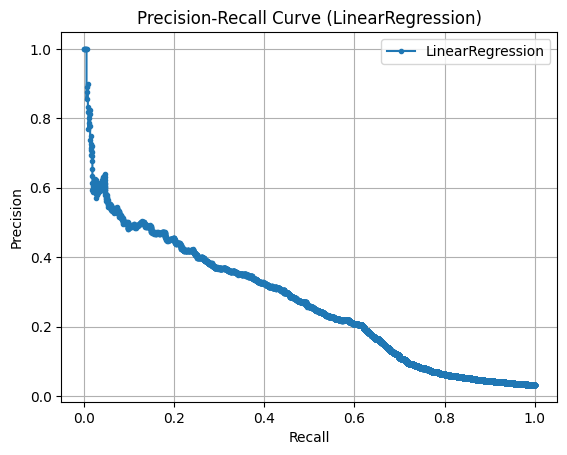

2025-06-07 13:33:05,274 - INFO - Berechne Metriken für Ridge



Ridge
Confusion Matrix:
 [[29951   188]
 [  835   165]]
Accuracy: 0.967
Precision: 0.467
Recall: 0.165
F1-Score: 0.244
ROC-AUC: 0.810
Custom Score (Kostenfunktion): -7137.960
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98     30139
           1       0.47      0.17      0.24      1000

    accuracy                           0.97     31139
   macro avg       0.72      0.58      0.61     31139
weighted avg       0.96      0.97      0.96     31139



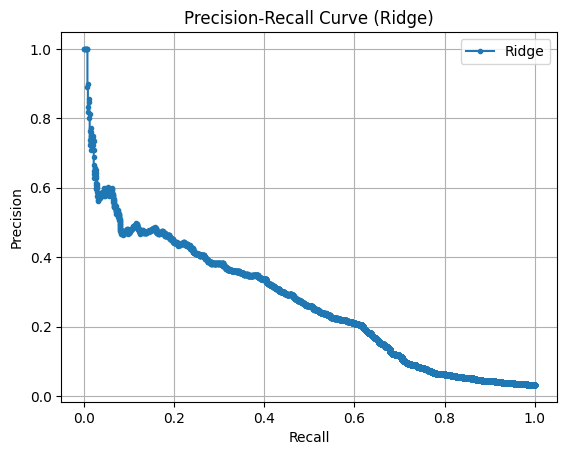

2025-06-07 13:33:16,859 - INFO - Berechne Metriken für Lasso



Lasso
Confusion Matrix:
 [[    0 30139]
 [    0  1000]]
Accuracy: 0.032
Precision: 0.032
Recall: 1.000
F1-Score: 0.062
ROC-AUC: 0.500
Custom Score (Kostenfunktion): -296390.000
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00     30139
           1       0.03      1.00      0.06      1000

    accuracy                           0.03     31139
   macro avg       0.02      0.50      0.03     31139
weighted avg       0.00      0.03      0.00     31139



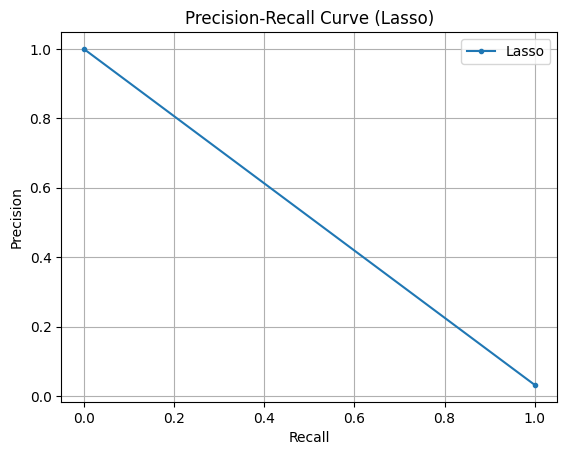

2025-06-07 13:33:27,813 - INFO - Berechne Metriken für DecisionTree



DecisionTree
Confusion Matrix:
 [[30139     0]
 [ 1000     0]]
Accuracy: 0.968
Precision: 0.000
Recall: 0.000
F1-Score: 0.000
ROC-AUC: 0.603
Custom Score (Kostenfunktion): -7881.000
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     30139
           1       0.00      0.00      0.00      1000

    accuracy                           0.97     31139
   macro avg       0.48      0.50      0.49     31139
weighted avg       0.94      0.97      0.95     31139



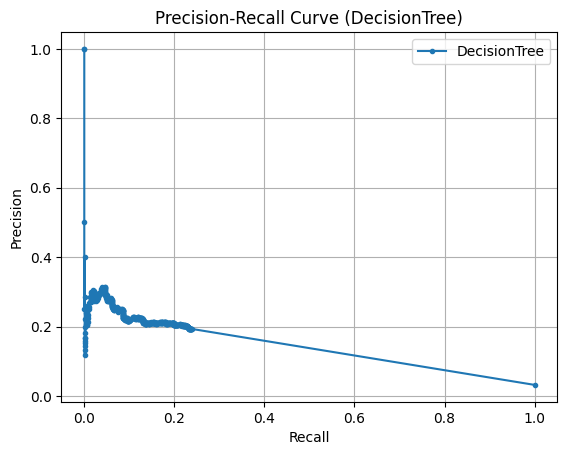

2025-06-07 13:33:43,850 - INFO - Berechne Metriken für RandomForest



RandomForest
Confusion Matrix:
 [[30082    57]
 [  876   124]]
Accuracy: 0.970
Precision: 0.685
Recall: 0.124
F1-Score: 0.210
ROC-AUC: 0.796
Custom Score (Kostenfunktion): -6563.200
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     30139
           1       0.69      0.12      0.21      1000

    accuracy                           0.97     31139
   macro avg       0.83      0.56      0.60     31139
weighted avg       0.96      0.97      0.96     31139



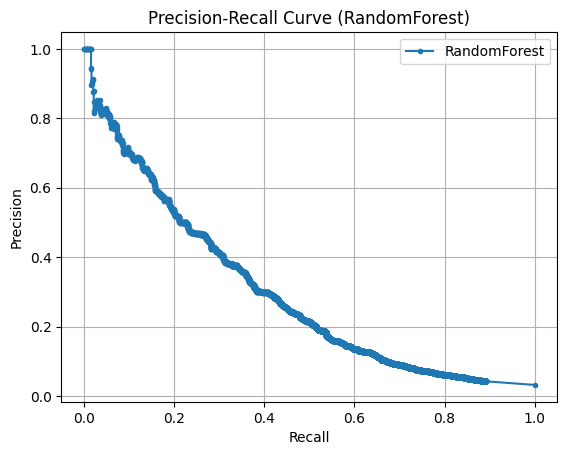

2025-06-07 13:36:31,269 - INFO - Berechne Metriken für GradientBoosting



GradientBoosting
Confusion Matrix:
 [[30029   110]
 [  780   220]]
Accuracy: 0.971
Precision: 0.667
Recall: 0.220
F1-Score: 0.331
ROC-AUC: 0.834
Custom Score (Kostenfunktion): -5706.880
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99     30139
           1       0.67      0.22      0.33      1000

    accuracy                           0.97     31139
   macro avg       0.82      0.61      0.66     31139
weighted avg       0.96      0.97      0.96     31139



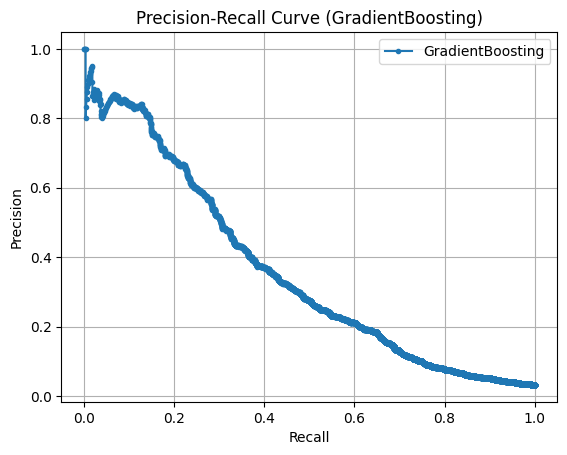

2025-06-07 13:39:11,403 - INFO - Berechne Metriken für XGBoost



XGBoost
Confusion Matrix:
 [[30069    70]
 [  894   106]]
Accuracy: 0.969
Precision: 0.602
Recall: 0.106
F1-Score: 0.180
ROC-AUC: 0.792
Custom Score (Kostenfunktion): -6860.080
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     30139
           1       0.60      0.11      0.18      1000

    accuracy                           0.97     31139
   macro avg       0.79      0.55      0.58     31139
weighted avg       0.96      0.97      0.96     31139



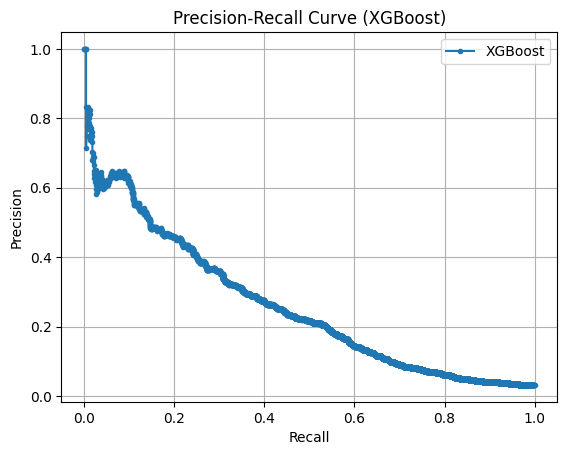

2025-06-07 13:39:34,463 - INFO - Berechne Metriken für LightGBM


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036019 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2203
[LightGBM] [Info] Number of data points in the train set: 124553, number of used features: 38
[LightGBM] [Info] Start training from score 0.252696
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.034301 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2203
[LightGBM] [Info] Number of data points in the train set: 124553, number of used features: 38
[LightGBM] [Info] Start training from score 0.252696

LightGBM
Confusion Matrix:
 [[30021   118]
 [  802   198]]
Accuracy: 0.970
Precision: 0.627
Recall: 0.198
F1-Score: 0.301
ROC-AUC: 0.832
Custom Score (Kostenfunktion): -6084.780
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     30139
  

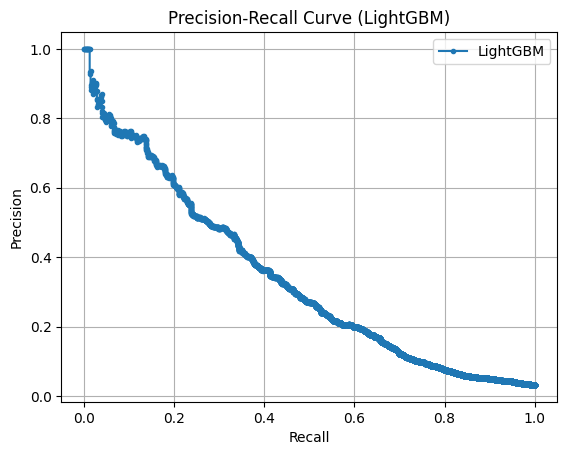

2025-06-07 13:39:57,083 - INFO - Berechne Metriken für CatBoost



CatBoost
Confusion Matrix:
 [[30002   137]
 [  798   202]]
Accuracy: 0.970
Precision: 0.596
Recall: 0.202
F1-Score: 0.302
ROC-AUC: 0.806
Custom Score (Kostenfunktion): -6175.700
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     30139
           1       0.60      0.20      0.30      1000

    accuracy                           0.97     31139
   macro avg       0.78      0.60      0.64     31139
weighted avg       0.96      0.97      0.96     31139



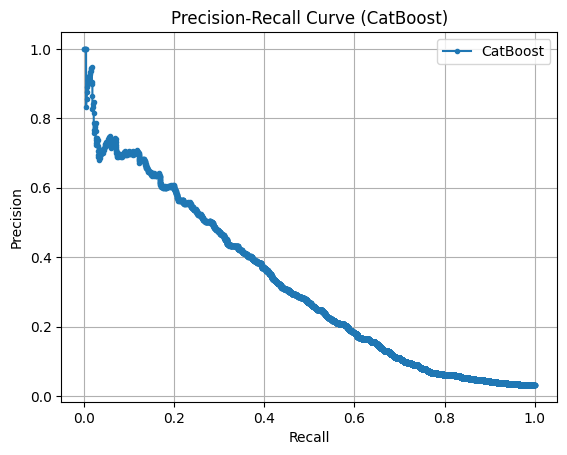


Gesamtergebnis aller Modelle:

              Model  Threshold  Accuracy  Precision  Recall  F1-Score  \
5  GradientBoosting   3.116948  0.971418   0.666667   0.220  0.330827   
7          LightGBM   3.397532  0.970455   0.626582   0.198  0.300912   
8          CatBoost   3.427953  0.969973   0.595870   0.202  0.301718   
4      RandomForest   5.802844  0.970038   0.685083   0.124  0.209992   
6           XGBoost   5.623552  0.969042   0.602273   0.106  0.180272   
1             Ridge   1.735425  0.967147   0.467422   0.165  0.243902   
0  LinearRegression   1.729660  0.967244   0.473262   0.177  0.257642   
3      DecisionTree  61.155556  0.967886   0.000000   0.000  0.000000   
2             Lasso   0.000000  0.032114   0.032114   1.000  0.062230   

    ROC-AUC  Custom_Score  
5  0.833965      -5706.88  
7  0.832047      -6084.78  
8  0.805822      -6175.70  
4  0.795809      -6563.20  
6  0.792398      -6860.08  
1  0.809672      -7137.96  
0  0.810859      -7140.65  
3  0.603479  

In [9]:
from sklearn.metrics import (
    classification_report, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, 
    roc_auc_score, RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay, accuracy_score
)

def evaluate_classification_metrics(y_true, y_scores, threshold):
    y_pred = (y_scores >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_scores)
    report = classification_report(y_true, y_pred, zero_division=0)
    
    return cm, precision, recall, accuracy, f1, roc_auc, report

# Ergebnisliste initialisieren
results_list = []

for name, pipeline in pipelines.items():
    logging.info(f"Berechne Metriken für {name}")
    
    pipeline.fit(X_train, damage_train)
    y_scores = pipeline.predict(X_test)
    
    best_score, best_threshold = evaluate_model(
        pipeline, 
        X_train, damage_train, y_train, 
        X_test, damage_test, y_test
    )
    
    cm, precision, recall, accuracy, f1, roc_auc, report = evaluate_classification_metrics(y_test, y_scores, best_threshold)
    
    results_list.append({
        'Model': name,
        'Threshold': best_threshold,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Custom_Score': best_score
    })
    
    print(f"\n{name}")
    print("Confusion Matrix:\n", cm)
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-Score: {f1:.3f}")
    print(f"ROC-AUC: {roc_auc:.3f}")
    print(f"Custom Score (Kostenfunktion): {best_score:.3f}")
    print("Classification Report:\n", report)
    
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)
    plt.figure()
    plt.plot(recalls, precisions, marker='.', label=f'{name}')
    plt.title(f'Precision-Recall Curve ({name})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid()
    plt.show()

final_results_df = pd.DataFrame(results_list).sort_values(by='Custom_Score', ascending=False)
print("\nGesamtergebnis aller Modelle:\n")
print(final_results_df)
